# Imports

In [1]:
import numpy as _np
import matplotlib.pyplot as _plt
import h5py as _h5
import glob

import os
import sys
parent_folder = os.path.abspath('..')
if parent_folder not in sys.path:
    sys.path.append(parent_folder)
import generatePtarmiganFiles

### Date and prefix

In [2]:
date = "2026_06_29"
save_name_prefix = "plots/ptarmigan/" + date + "_plot"

## Plots

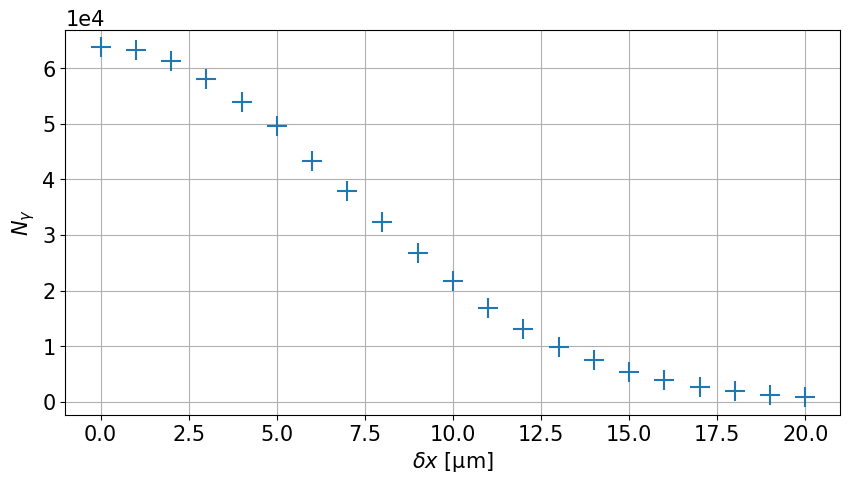

In [33]:
data_dict = generatePtarmiganFiles.ReadPicke("../../00_ptarmigan/pickles_V2/000_luxe_position_offset_scan_X_n_100000.pickle")
X='OffsetX'
Y='Nbphoton'
unit='offset_unit'

_plt.rcParams['font.size'] = 15
_plt.figure(figsize=[10, 5])
_plt.plot(_np.array(data_dict[X])*1e3, data_dict[Y], ls='', marker='+', markersize=15, markeredgewidth=1.5)
_plt.ylabel(r"$N_\gamma$")
_plt.xlabel(r"$\delta x$ [$\rm \mu m$]")
_plt.grid()
_plt.ticklabel_format(axis="y", style='sci', scilimits=(0, 0))
_plt.savefig("{}_Offset_X_Scan_Photons".format(save_name_prefix), dpi=300, bbox_inches='tight')

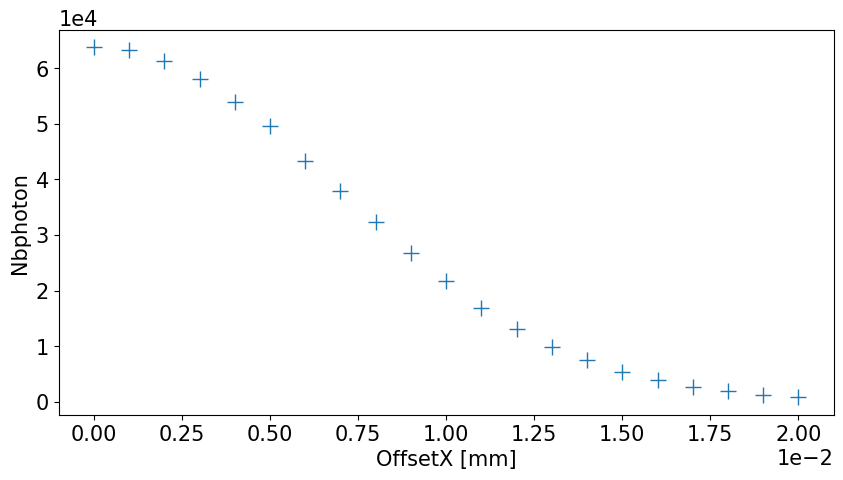

In [15]:
generatePtarmiganFiles.plotCurve("../../00_ptarmigan/pickles_V2/000_luxe_position_offset_scan_X_n_100000.pickle", 
                                 X='OffsetX', Y='Nbphoton', unit='offset_unit', figsize=[10, 5])
# _plt.savefig("{}_Offset_X_Scan_Photons".format(save_name_prefix), dpi=300, bbox_inches='tight')

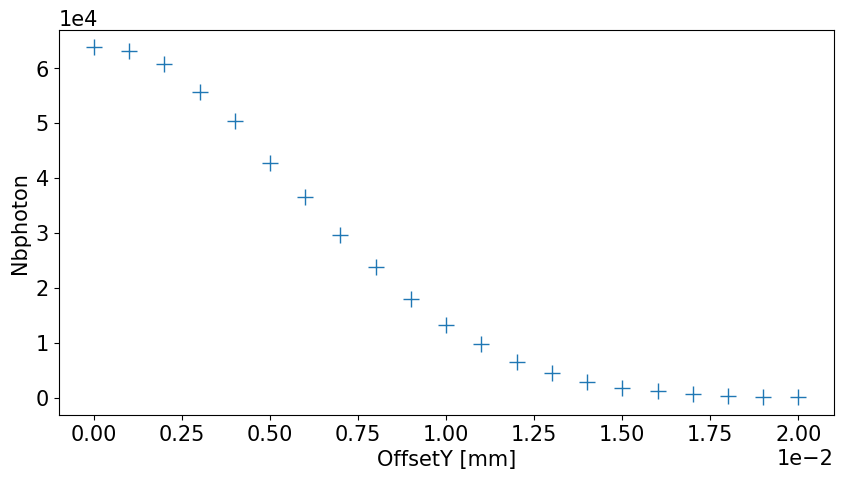

In [4]:
generatePtarmiganFiles.plotCurve("../../00_ptarmigan/pickles/000_luxe_position_offset_scan_Y_n_100000.pickle", 
                                 X='OffsetY', Y='Nbphoton', unit='offset_unit', figsize=[10, 5])
_plt.savefig("{}_Offset_Y_Scan_Photons".format(save_name_prefix), dpi=300, bbox_inches='tight')

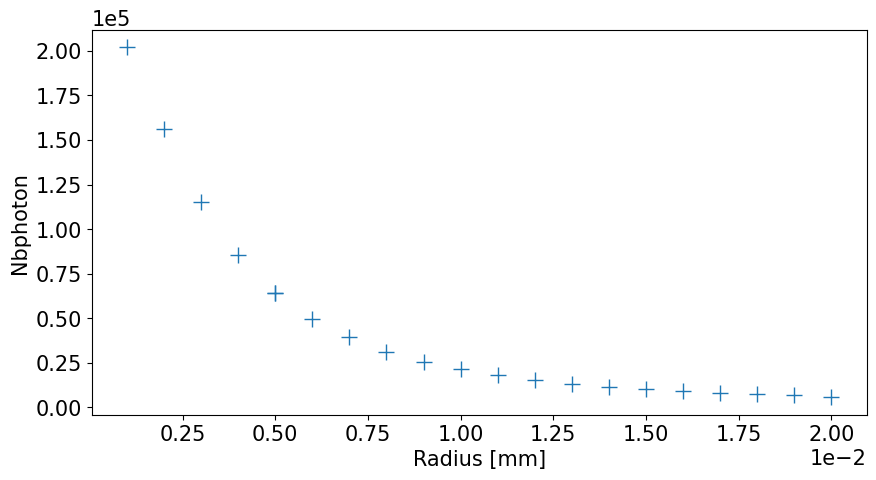

In [5]:
generatePtarmiganFiles.plotCurve("../../00_ptarmigan/pickles/000_luxe_radius_offset_scan_n_100000.pickle", 
                                 X='Radius', Y='Nbphoton', unit='radius_unit', figsize=[10, 5])
_plt.savefig("{}_Offset_Radius_Scan_Photons".format(save_name_prefix), dpi=300, bbox_inches='tight')

## Reference (no jitter)

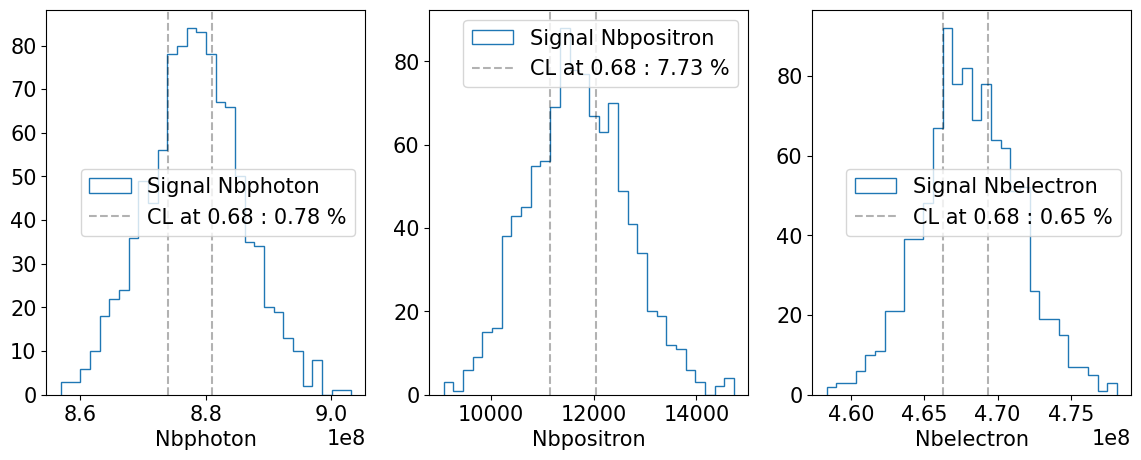

In [6]:
generatePtarmiganFiles.plotAllParticlesCL("../../00_ptarmigan/pickles_old/LUXE_reference_no_jitter_X_n_50000_npoints_1000_sigma_0.pickle", 
                                          nbins=30, value=0.68, cumulative=False, figsize=[14, 5])
_plt.savefig("{}_Reference_no_Jitter_Scan_n_50000".format(save_name_prefix), dpi=300, bbox_inches='tight')

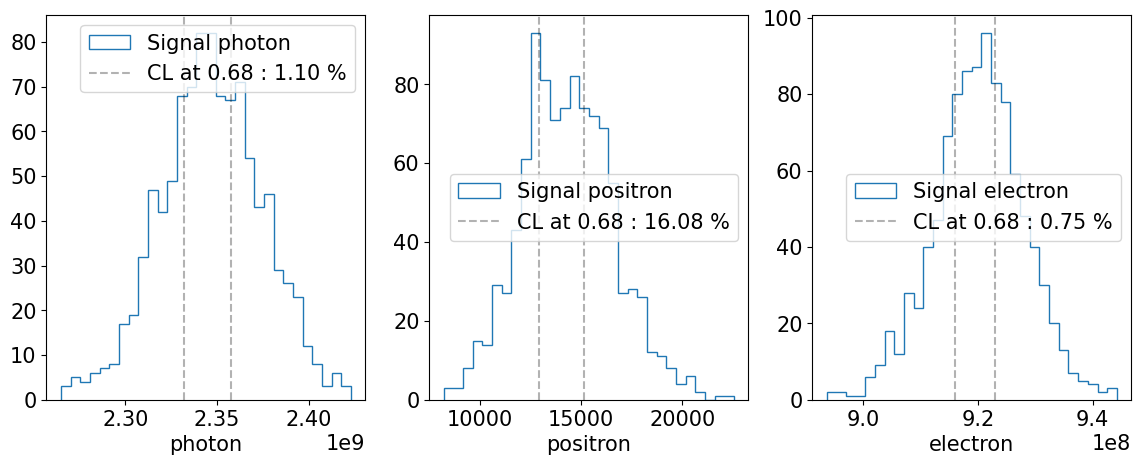

In [6]:
generatePtarmiganFiles.plotAllParticlesCL("../../00_ptarmigan/pickles/LUXE_position_jitter_scan_X_ngen_10000_npts_1000_mu_0.00e+00_sigma_2.00e-07.pickle", 
                                          nbins=30, value=0.68, cumulative=False, figsize=[14, 5])

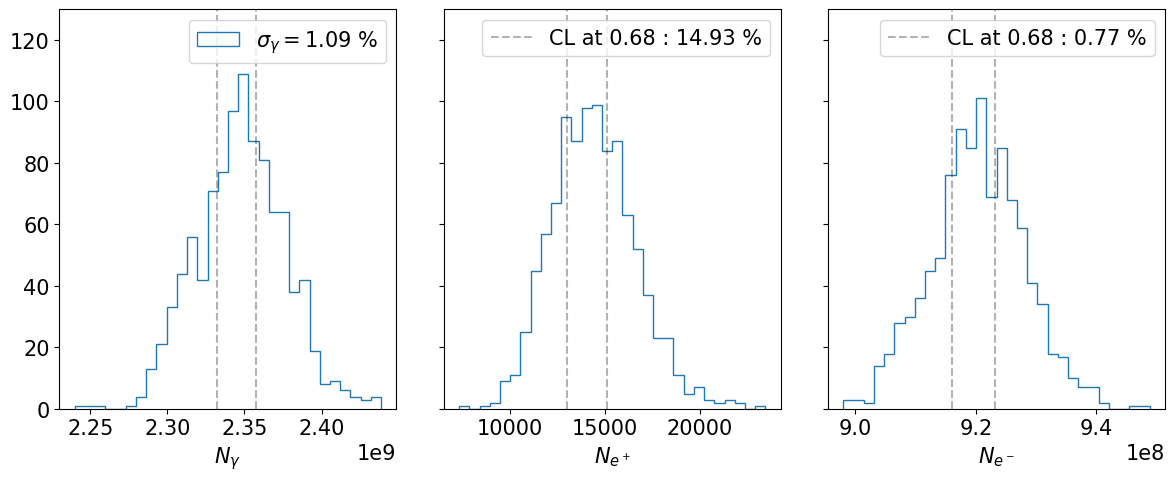

In [29]:
generatePtarmiganFiles.plotAllParticlesCL("../../00_ptarmigan/pickles/LUXE_reference_no_jitter_ngen_10000_npts_1000.pickle", 
                                          nbins=30, value=0.68, cumulative=False, figsize=[12, 5])
_plt.rcParams['font.size'] = 15
_plt.tight_layout()
_plt.ylim(0, 130)
fig = _plt.gcf()
fig.axes[0].set_xlabel(r"$N_\gamma$")
fig.axes[0].legend([r"$\sigma_\gamma= 1.09\ \%$"])
fig.axes[1].set_xlabel(r"$N_{e^+}$")
fig.axes[2].set_xlabel(r"$N_{e^-}$");
# _plt.savefig("{}_Reference_no_Jitter_Scan_ngen_10000_npts_1000".format(save_name_prefix), dpi=300, bbox_inches='tight')

In [13]:
data_dict = generatePtarmiganFiles.ReadPicke("../../00_ptarmigan/pickles/LUXE_reference_no_jitter_ngen_10000_npts_1000.pickle")
upper_cl, lower_cl, mode = generatePtarmiganFiles.calcCumulativeLength(data_dict['photon']['Nbparticle'])
variation = generatePtarmiganFiles.calcVariation(upper_cl, lower_cl, mode)

In [19]:
N_gamma_list = data_dict['photon']['Nbparticle']

In [21]:
N_gamma_mean = _np.mean(N_gamma_list)
N_gamma_std = _np.std(N_gamma_list)

In [22]:
N_gamma_std/N_gamma_mean * 100

np.float64(1.2147827067811248)

## X/Y jitter

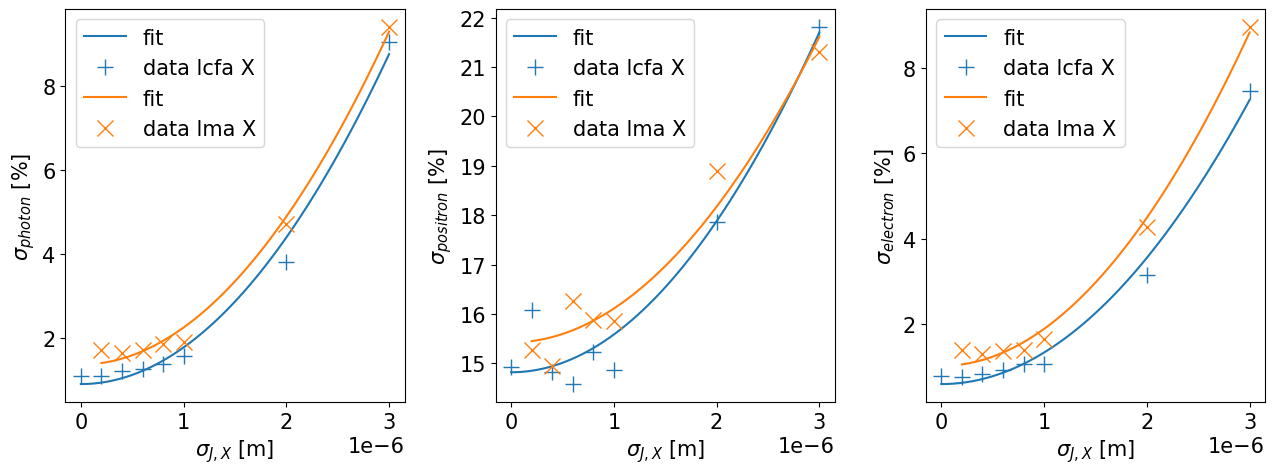

In [37]:
regex_x = "../../00_ptarmigan/pickles/LUXE_position_jitter_scan_X_ngen_10000_npts_1000_*"
regex_y = "../../00_ptarmigan/pickles/LUXE_lma_position_jitter_scan_X_ngen_10000_npts_1000_*"
generatePtarmiganFiles.plotAllResOnRes(regex_x, regex_y=regex_y, nbins=30, value=0.68, labelX="lcfa X", labelY="lma X", labelXY="X", unit='m', 
                                       fit=True, fitparams=[[1e10, 1], [1e10, 1], [1e10, 1]], 
                                       mark_x=None, mark_y=None, figsize=[13, 5])
_plt.savefig("{}_Jitter_lma_lcfa_X_Scan_n_10000_npoints_1000".format(save_name_prefix), dpi=300, bbox_inches='tight')

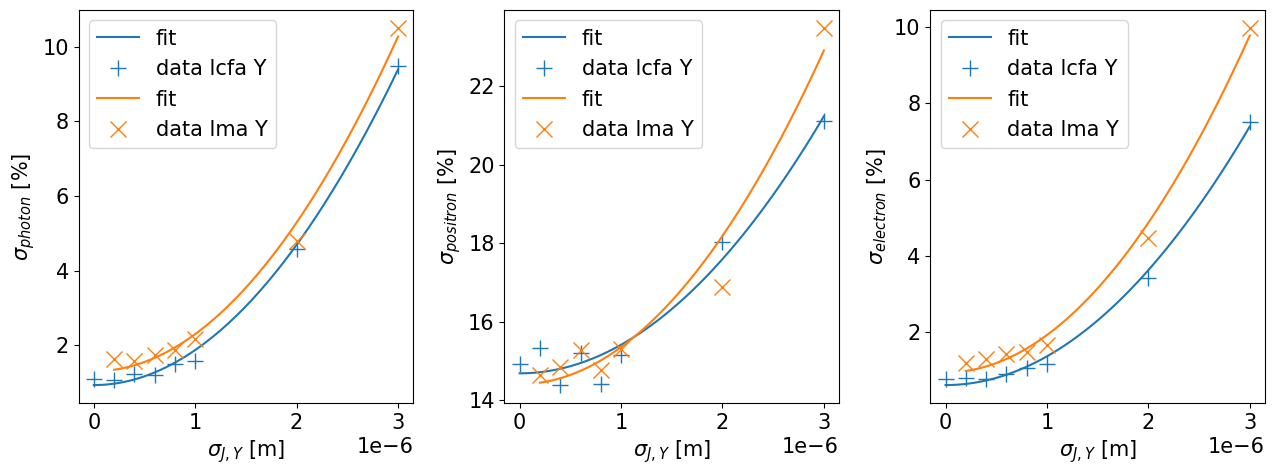

In [39]:
regex_x = "../../00_ptarmigan/pickles/LUXE_position_jitter_scan_Y_ngen_10000_npts_1000_*"
regex_y = "../../00_ptarmigan/pickles/LUXE_lma_position_jitter_scan_Y_ngen_10000_npts_1000_*"
generatePtarmiganFiles.plotAllResOnRes(regex_x, regex_y=regex_y, nbins=30, value=0.68, labelX="lcfa Y", labelY="lma Y", labelXY="Y", unit='m', 
                                       fit=True, fitparams=[[1e10, 1], [1e10, 1], [1e10, 1]], 
                                       mark_x=None, mark_y=None, figsize=[13, 5])
_plt.savefig("{}_Jitter_lma_lcfa_X_Scan_n_10000_npoints_1000".format(save_name_prefix), dpi=300, bbox_inches='tight')

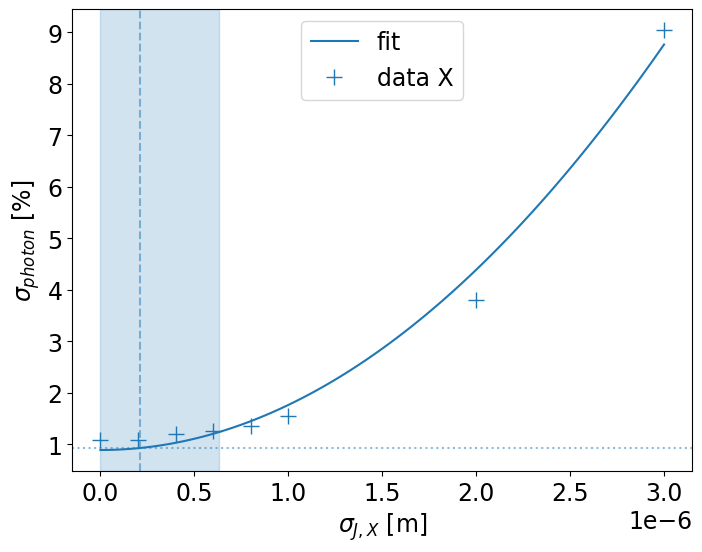

In [3]:
regex_x = "../../00_ptarmigan/pickles/LUXE_position_jitter_scan_X_ngen_10000_npts_1000_*"
_plt.rcParams['font.size'] = 17
fig = _plt.figure(figsize=[8, 6])
generatePtarmiganFiles.plotXYResolutionOnResolution(regex_x, regex_y=None, nbins=30, value=0.68, 
                                                    labelX="X", labelY="Y", labelXY="X", unit='m', 
                                                    fit=True, fitparam=[1e10, 1], 
                                                    mark_x=0.21e-6, mark_y=None)
ax = _plt.gca()
ax.axvspan(0, 0.63e-6, color='C0', alpha=0.2)
_plt.ylabel("$\sigma_{photon}$ [%]")
_plt.savefig("{}_Jitter_X_Scan_n_10000_npoints_1000_photons.pdf".format(save_name_prefix), dpi=300, bbox_inches='tight')

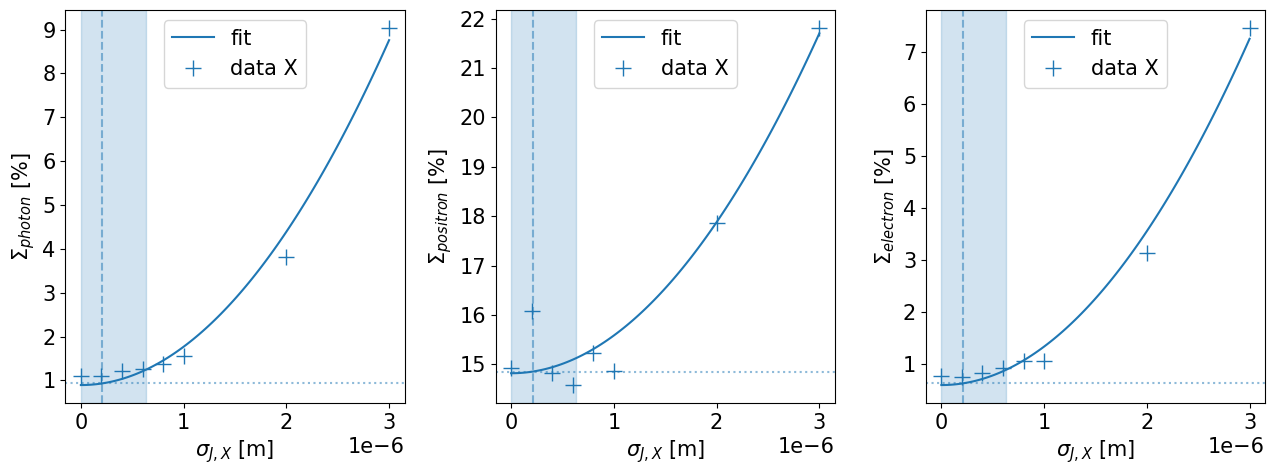

In [3]:
regex_x = "../../00_ptarmigan/pickles/LUXE_position_jitter_scan_X_ngen_10000_npts_1000_*"
generatePtarmiganFiles.plotAllResOnRes(regex_x, regex_y=None, nbins=30, value=0.68, labelX="X", labelY="Y", labelXY="X", unit='m', 
                                       fit=True, fitparams=[[1e10, 1], [1e10, 1], [1e10, 1]], 
                                       mark_x=0.21e-6, mark_y=None, figsize=[13, 5])
fig = _plt.gcf()
axes = fig.get_axes()
for ax in axes:
    ax.axvspan(0, 0.63e-6, color='C0', alpha=0.2)
_plt.savefig("{}_Jitter_X_Scan_n_10000_npoints_1000.pdf".format(save_name_prefix), dpi=300, bbox_inches='tight')

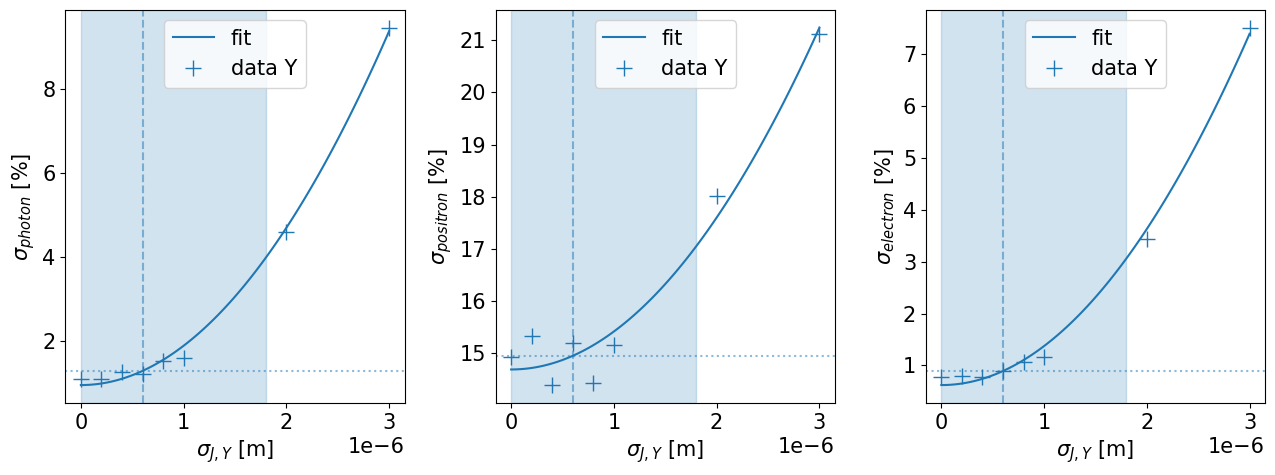

In [6]:
regex_y = "../../00_ptarmigan/pickles/LUXE_position_jitter_scan_Y_ngen_10000_npts_1000_*"
generatePtarmiganFiles.plotAllResOnRes(regex_y, regex_y=None, nbins=30, value=0.68, labelX="Y", labelY="Y", labelXY="Y", unit='m', 
                                       fit=True, fitparams=[[1e10, 1], [1e10, 1], [1e10, 1]], 
                                       mark_x=0.6e-6, mark_y=None, figsize=[13, 5])
fig = _plt.gcf()
axes = fig.get_axes()
for ax in axes:
    ax.axvspan(0, 1.8e-6, color='C0', alpha=0.2)
_plt.savefig("{}_Jitter_Y_Scan_n_10000_npoints_1000".format(save_name_prefix), dpi=300, bbox_inches='tight')

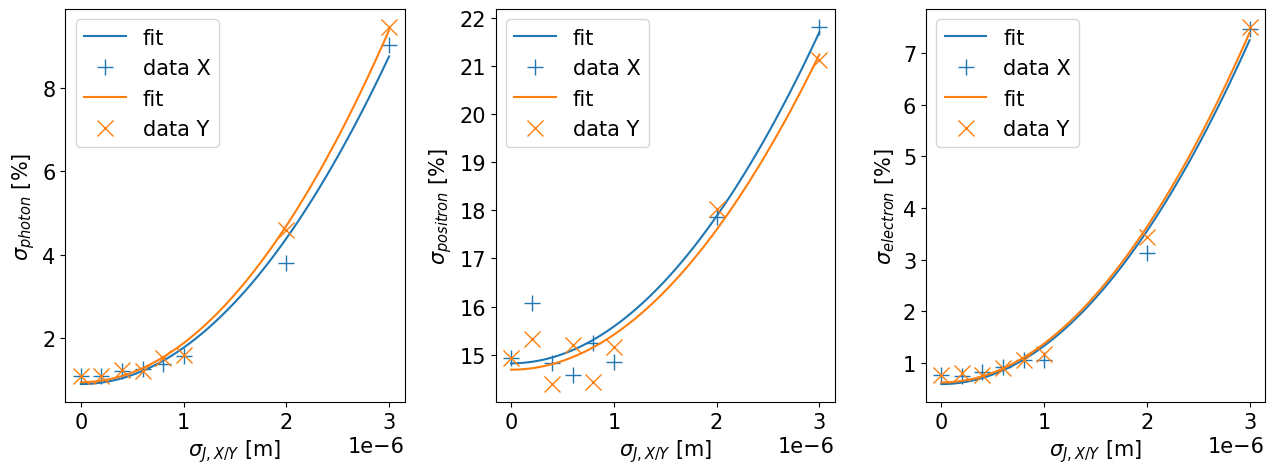

In [33]:
regex_x = "../../00_ptarmigan/pickles/LUXE_position_jitter_scan_X_ngen_10000_npts_1000_*"
regex_y = "../../00_ptarmigan/pickles/LUXE_position_jitter_scan_Y_ngen_10000_npts_1000_*"
generatePtarmiganFiles.plotAllResOnRes(regex_x, regex_y=regex_y, nbins=30, value=0.68, labelX="X", labelY="Y", labelXY="X/Y", unit='m', 
                                       fit=True, fitparams=[[1e10, 1], [1e10, 1], [1e10, 1]], 
                                       mark_x=None, mark_y=None, figsize=[13, 5])
fig = _plt.gcf()
axes = fig.get_axes()
#for ax in axes:
#    ax.axvspan(0, 0.63e-6, color='C0', alpha=0.2)
#    ax.axvspan(0, 1.8e-6, color='C1', alpha=0.2)
_plt.savefig("{}_Jitter_XY_Scan_n_10000_npoints_1000".format(save_name_prefix), dpi=300, bbox_inches='tight')

## Z jitter

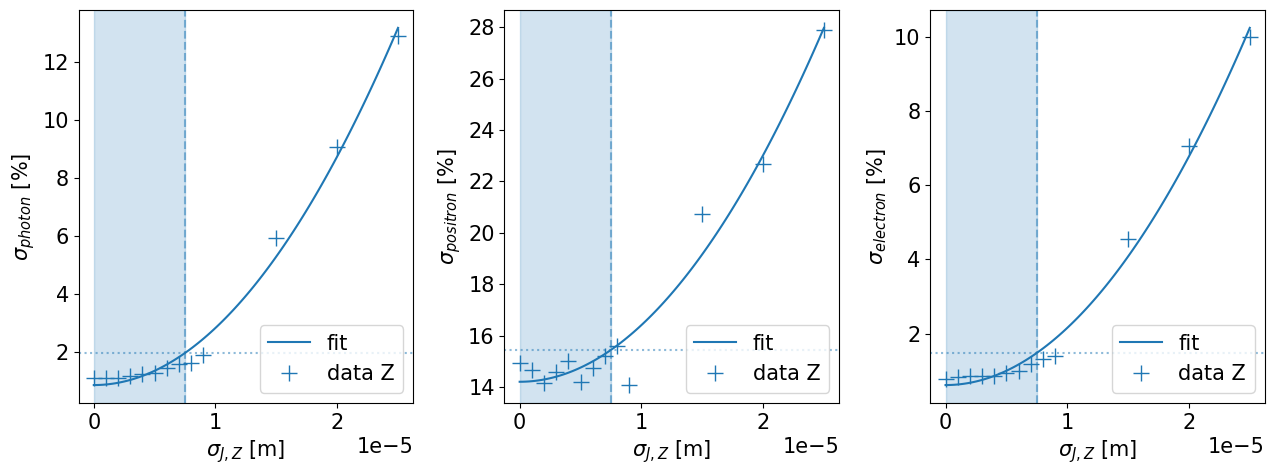

In [29]:
regex_z = "../../00_ptarmigan/pickles/LUXE_position_jitter_scan_Z_ngen_10000_npts_1000_*"
generatePtarmiganFiles.plotAllResOnRes(regex_z, regex_y=None, nbins=30, value=0.68, labelX="Z", labelXY="Z", unit='m', 
                                       fit=True, fitparams=[[1e10, 1], [1e10, 1], [1e10, 1]], 
                                       mark_x=7.5e-6, mark_y=None, figsize=[13, 5])
fig = _plt.gcf()
axes = fig.get_axes()
for ax in axes:
    ax.axvspan(0, 7.5e-6, color='C0', alpha=0.2)

_plt.savefig("{}_Jitter_Z_Scan_n_10000_npoints_1000".format(save_name_prefix), dpi=300, bbox_inches='tight')

## Angle Jitter

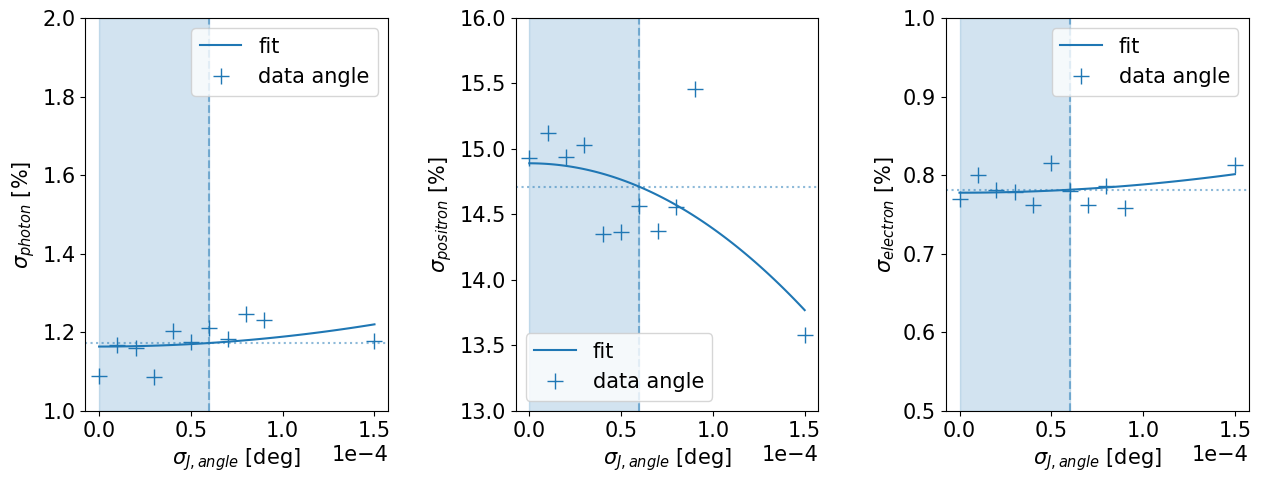

In [9]:
regex_angle = "../../00_ptarmigan/pickles/LUXE_angle_jitter_scan_ngen_10000_npts_1000_*"
generatePtarmiganFiles.plotAllResOnRes(regex_angle, regex_y=None, nbins=30, value=0.68, labelX="angle", labelXY="angle", unit='deg', 
                                       fit=True, fitparams=[[1e10, 1], [1e10, 1], [1e10, 1]], 
                                       mark_x=6e-5, mark_y=None, figsize=[13, 5])
fig = _plt.gcf()
axes = fig.get_axes()
for ax in axes:
    ax.axvspan(0, 6e-5, color='C0', alpha=0.2)
axes[0].set_ylim(1, 2)
axes[1].set_ylim(13, 16)
axes[2].set_ylim(0.5, 1)
_plt.savefig("{}_Jitter_Angle_Scan_n_10000_npoints_1000".format(save_name_prefix), dpi=300, bbox_inches='tight')

## Energy Jitter

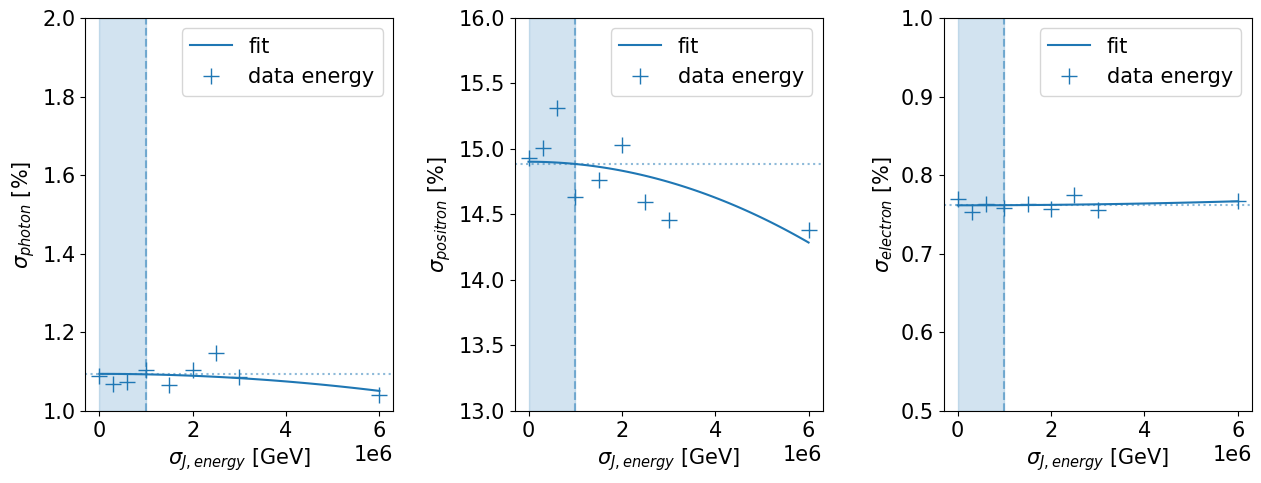

In [24]:
regex_energy = "../../00_ptarmigan/pickles/LUXE_energy_jitter_scan_ngen_10000_npts_1000_*"
generatePtarmiganFiles.plotAllResOnRes(regex_energy, regex_y=None, nbins=30, value=0.68, labelX="energy", labelXY="energy", unit='GeV', 
                                       fit=True, fitparams=[[1e10, 1], [1e10, 1], [1e10, 1]], 
                                       mark_x=1e6, mark_y=None, figsize=[13, 5])
fig = _plt.gcf()
axes = fig.get_axes()
for ax in axes:
    ax.axvspan(0, 1e6, color='C0', alpha=0.2)
axes[0].set_ylim(1, 2)
axes[1].set_ylim(13, 16)
axes[2].set_ylim(0.5, 1)
_plt.savefig("{}_Jitter_Energy_Scan_n_10000_npoints_1000".format(save_name_prefix), dpi=300, bbox_inches='tight')

## Charge Jitter

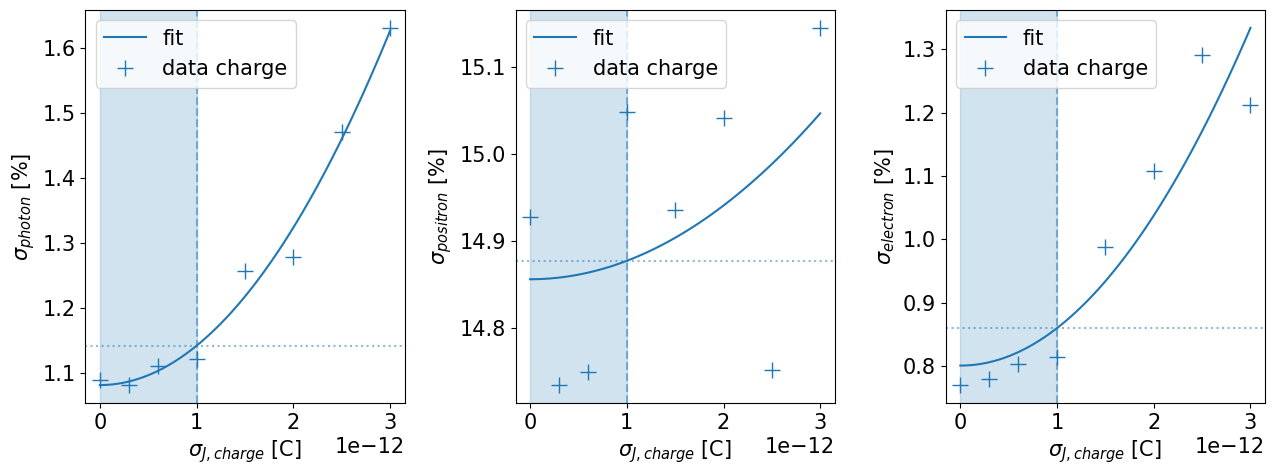

In [25]:
regex_charge = "../../00_ptarmigan/pickles/LUXE_charge_jitter_scan_ngen_10000_npts_1000_*"
generatePtarmiganFiles.plotAllResOnRes(regex_charge, regex_y=None, nbins=30, value=0.68, labelX="charge", labelXY="charge", unit='C', 
                                       fit=True, fitparams=[[1e20, 1], [1e20, 1], [1e20, 1]], 
                                       mark_x=1e-12, mark_y=None, figsize=[13, 5])
fig = _plt.gcf()
axes = fig.get_axes()
for ax in axes:
    ax.axvspan(0, 1e-12, color='C0', alpha=0.2)
_plt.savefig("{}_Jitter_Charge_Scan_n_10000_npoints_1000".format(save_name_prefix), dpi=300, bbox_inches='tight')

## Length Jitter

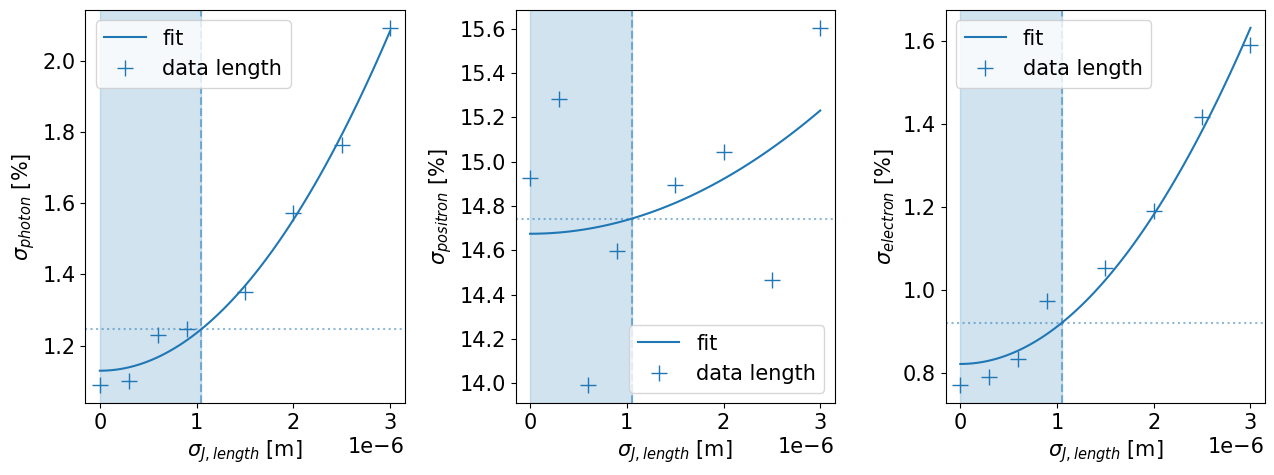

In [26]:
regex_length = "../../00_ptarmigan/pickles/LUXE_length_jitter_scan_ngen_10000_npts_1000_*"
generatePtarmiganFiles.plotAllResOnRes(regex_length, regex_y=None, nbins=30, value=0.68, labelX="length", labelXY="length", unit='m', 
                                       fit=True, fitparams=[[1e10, 1], [1e10, 1], [1e10, 1]], 
                                       mark_x=1.05e-6, mark_y=None, figsize=[13, 5])
fig = _plt.gcf()
axes = fig.get_axes()
for ax in axes:
    ax.axvspan(0, 1.05e-6, color='C0', alpha=0.2)
_plt.savefig("{}_Jitter_Length_Scan_n_10000_npoints_1000".format(save_name_prefix), dpi=300, bbox_inches='tight')

## Size Jitter

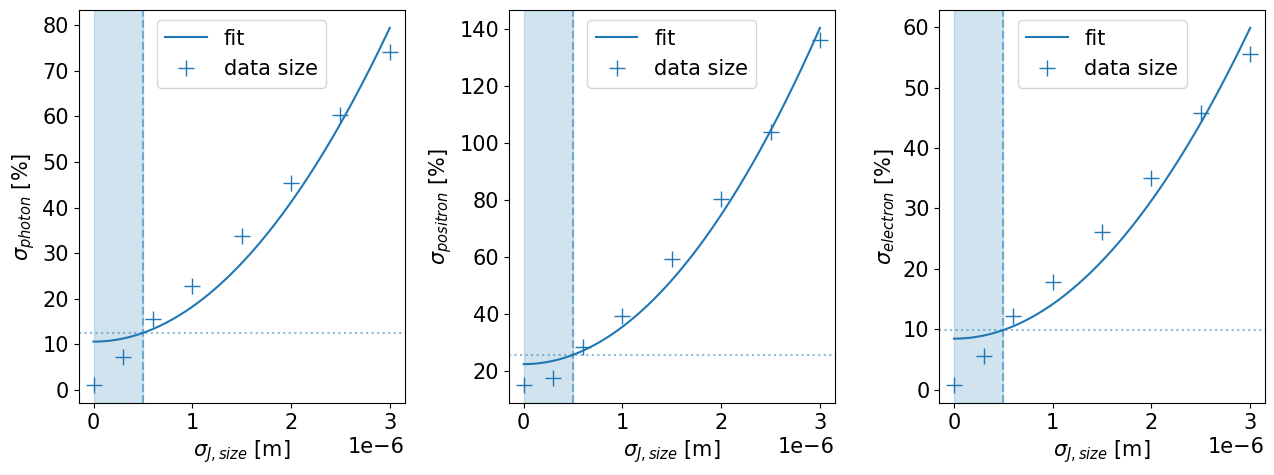

In [27]:
regex_size = "../../00_ptarmigan/pickles/LUXE_size_jitter_scan_ngen_10000_npts_1000_*"
generatePtarmiganFiles.plotAllResOnRes(regex_size, regex_y=None, nbins=30, value=0.68, labelX="size", labelXY="size", unit='m', 
                                       fit=True, fitparams=[[1e10, 1], [1e10, 1], [1e10, 1]], 
                                       mark_x=0.5e-6, mark_y=None, figsize=[13, 5])
fig = _plt.gcf()
axes = fig.get_axes()
for ax in axes:
    ax.axvspan(0, 0.5e-6, color='C0', alpha=0.2)
_plt.savefig("{}_Jitter_Size_Scan_n_10000_npoints_1000".format(save_name_prefix), dpi=300, bbox_inches='tight')

# Energy spectrum

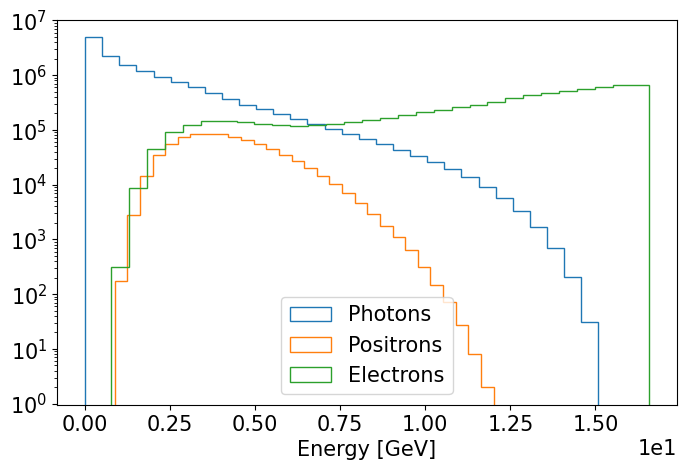

In [16]:
inputfilename = "../../00_ptarmigan/pickles_old/LUXE_reference_no_jitter_X_n_15000_npoints_1500_sigma_0.0e+00.pickle"
generatePtarmiganFiles.plotAllHist(inputfilename, param='Energy', unit='GeV', nbins=30, figsize=[8, 5])
_plt.yscale('log')
_plt.savefig("{}_Energy_Spectrum_15000_npoints_1500".format(save_name_prefix), dpi=300, bbox_inches='tight')